<a href="https://colab.research.google.com/github/anirbankhan/AI_Model_figo/blob/main/outlier_detection2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('placement.csv')

In [3]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


/tmp/ipython-input-174/2541405458.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])


<Axes: xlabel='placement_exam_marks', ylabel='Density'>

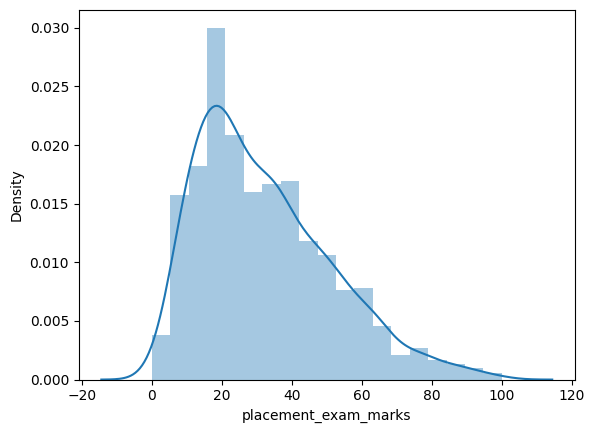

In [4]:
sns.distplot(df['placement_exam_marks'])

In [29]:
df.shape

(1000, 3)

<Axes: ylabel='placement_exam_marks'>

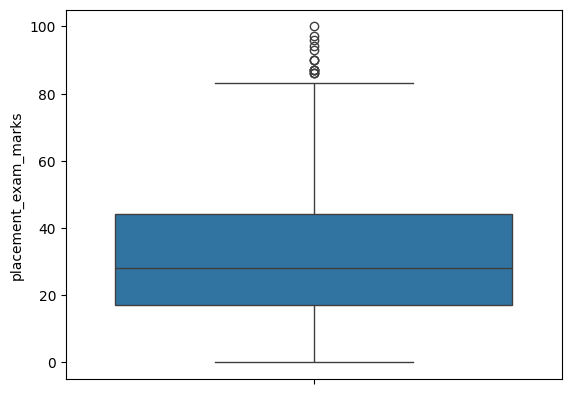

In [6]:
sns.boxplot(df['placement_exam_marks'])

In [7]:
# as the data is skewed we have to use IQR method to detect outlier
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)

In [13]:
iqr = percentile75 - percentile25

In [14]:
iqr

np.float64(27.0)

In [15]:
upper_limit = percentile75 + 1.5*iqr

In [16]:
upper_limit

np.float64(84.5)

In [17]:
lower_limit = percentile25 - 1.5*iqr

In [18]:
lower_limit

np.float64(-23.5)

In [26]:
# Finding outlier
df[(df['placement_exam_marks'] > upper_limit) | (df['placement_exam_marks'] < lower_limit) ].shape

(15, 3)

In [31]:
# New data after triming
new_df = df[(df['placement_exam_marks'] < upper_limit) & (df['placement_exam_marks'] > lower_limit) ]

<Axes: ylabel='placement_exam_marks'>

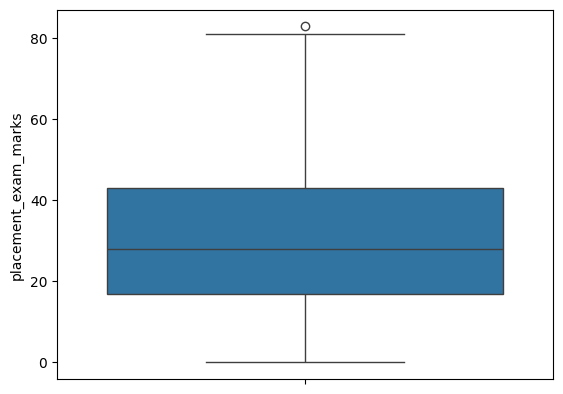

In [34]:
sns.boxplot(new_df['placement_exam_marks'])

In [39]:
new_df_cap = df.copy()

new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks'] > upper_limit,
    upper_limit,
    np.where(
        new_df_cap['placement_exam_marks'] < lower_limit,
        lower_limit,
        new_df_cap['placement_exam_marks']
    )
)

In [36]:
new_df.shape

(1000,)

In [41]:
new_df_cap['placement_exam_marks']

,placement_exam_marks
0,26.0
1,38.0
2,40.0
3,8.0
4,17.0
...,...
995,44.0
996,65.0
997,34.0
998,46.0
